# FarmTech Solutions — Fase 5
## Previsão de Rendimento de Safra e Descoberta de Tendências de Produtividade

**PBL de Inteligência Artificial — FIAP | Cap 01, Fase 5**

| Integrante | RM |
|---|---|
| Kainan Bilibio Aguiar | 570594 |
| Guilherme C. Ávila | 571294 |

---

### Contexto

A FarmTech Solutions presta serviços de Inteligência Artificial a uma fazenda de
médio porte — **200 hectares**, aproximadamente 210 campos de futebol oficiais —
que cultiva várias culturas simultaneamente.

A fazenda coleta, por meio de sensores em campo, quatro variáveis de solo e clima.
A pergunta de negócio é direta: **dadas as condições medidas, qual será o
rendimento da safra?** E, antes disso: **existe algum padrão recorrente que
agrupe as safras por comportamento produtivo?**

### Objetivo do notebook

1. **Análise exploratória** — entender a estrutura, a qualidade e o comportamento dos dados
2. **Aprendizado não supervisionado** — clusterizar para encontrar tendências de
   produtividade e identificar cenários discrepantes (*outliers*)
3. **Aprendizado supervisionado** — construir e comparar **cinco modelos de regressão**,
   cada um com um algoritmo diferente, avaliados por métricas pertinentes ao problema

### Sumário

- [0. Configuração do ambiente](#bloco0)
- [1. Análise Exploratória dos Dados](#bloco1)
- [2. Clusterização e detecção de outliers](#bloco2)
- [3. Modelagem preditiva — cinco algoritmos](#bloco3)
- [4. Conclusões, pontos fortes e limitações](#bloco4)


<a id="bloco0"></a>
## 0. Configuração do ambiente

Importações, semente aleatória fixa e padronização visual dos gráficos.

A semente (`RANDOM_STATE`) é fixada uma única vez e reutilizada em toda divisão
de dados e em todo algoritmo estocástico do notebook. Sem isso, cada execução
produziria métricas diferentes e a comparação entre os cinco modelos deixaria de
ser reprodutível.


In [1]:
# Manipulacao de dados
import pandas as pd
import numpy as np

# Visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

# Semente unica para todo o notebook - garante reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Padronizacao visual: mesma paleta e grid em todos os graficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

# Exibe numeros com 2 casas decimais e sem notacao cientifica
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_columns", None)

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 3.0.5 | numpy 2.5.2 | seaborn 0.13.2


In [2]:
# Caminho relativo a raiz do repositorio - o notebook e executado a partir dela
CAMINHO_DADOS = "dados/crop_yield.csv"

df_bruto = pd.read_csv(CAMINHO_DADOS)

print(f"Arquivo carregado: {CAMINHO_DADOS}")
print(f"Dimensoes: {df_bruto.shape[0]} observacoes x {df_bruto.shape[1]} colunas")

Arquivo carregado: dados/crop_yield.csv
Dimensoes: 156 observacoes x 6 colunas


<a id="bloco1"></a>
## 1. Análise Exploratória dos Dados

O objetivo desta seção é responder três perguntas antes de qualquer modelagem:
**o que há na base**, **a base tem qualidade suficiente** e **o que os dados já
revelam sozinhos**.

### 1.1 Estrutura e integridade


In [3]:
# Primeiras linhas - inspecao visual do formato bruto
df_bruto.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans","2,248.92",17.72,83.40,26.01,11560
1,"Cocoa, beans","1,938.42",17.54,82.11,26.11,11253
2,"Cocoa, beans","2,301.54",17.81,82.79,26.24,9456
3,"Cocoa, beans","2,592.35",17.61,85.07,25.56,9321
4,"Cocoa, beans","2,344.72",17.61,84.12,25.76,8800


In [4]:
# Tipos de dado e uso de memoria
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [5]:
# Contagem de valores ausentes e duplicados - diagnostico de qualidade
diagnostico = pd.DataFrame({
    "tipo": df_bruto.dtypes.astype(str),
    "nulos": df_bruto.isnull().sum(),
    "% nulos": (df_bruto.isnull().sum() / len(df_bruto) * 100).round(2),
    "valores unicos": df_bruto.nunique(),
})

print(f"Linhas duplicadas na base: {df_bruto.duplicated().sum()}")
diagnostico

Linhas duplicadas na base: 0


,tipo,nulos,% nulos,valores unicos
Crop,str,0,0.00,4
Precipitation (mm day-1),float64,0,0.00,39
Specific Humidity at 2 Meters (g/kg),float64,0,0.00,33
Relative Humidity at 2 Meters (%),float64,0,0.00,38
Temperature at 2 Meters (C),float64,0,0.00,29
Yield,int64,0,0.00,155


**Achado.** A base tem **156 observações** e **zero valores ausentes** em todas
as seis colunas — não há necessidade de imputação, remoção de linhas ou qualquer
tratamento de dados faltantes. Também não há linhas duplicadas.

Isso é incomum em dados reais de campo e sugere que a base já passou por um
processo de curadoria antes de ser disponibilizada. É um ponto positivo para a
modelagem, mas é também a primeira limitação a registrar: **um modelo treinado
em dados perfeitos não aprende a lidar com falha de sensor**, que é a realidade
de uma fazenda instrumentada.

### 1.2 Padronização dos nomes das colunas

Os cabeçalhos originais vêm em inglês, com unidade de medida embutida no nome e
com espaços e parênteses:

`Precipitation (mm day-1)`, `Specific Humidity at 2 Meters (g/kg)`, ...

Nomes assim são impraticáveis em fórmulas, em rótulos de gráfico e em qualquer
seleção por atributo. Renomeamos para identificadores curtos em português,
mantendo abaixo o dicionário de-para para rastreabilidade — a unidade não se
perde, apenas migra do nome da coluna para a documentação e para os eixos dos
gráficos.

> **Observação.** O enunciado do projeto descreve as variáveis em português.
> O arquivo entregue traz os cabeçalhos em inglês. O mapeamento abaixo torna
> essa correspondência explícita.


In [6]:
# Dicionario de-para: cabecalho original -> identificador curto
MAPA_COLUNAS = {
    "Crop":                                  "cultura",
    "Precipitation (mm day-1)":              "precipitacao",
    "Specific Humidity at 2 Meters (g/kg)":  "umid_especifica",
    "Relative Humidity at 2 Meters (%)":     "umid_relativa",
    "Temperature at 2 Meters (C)":           "temperatura",
    "Yield":                                 "rendimento_bruto",
}

# Unidades preservadas para uso nos rotulos dos graficos
UNIDADES = {
    "precipitacao":    "mm/dia",
    "umid_especifica": "g/kg",
    "umid_relativa":   "%",
    "temperatura":     "°C",
}

df = df_bruto.rename(columns=MAPA_COLUNAS)

# Tabela de rastreabilidade do renomeio
pd.DataFrame(
    {"cabecalho original": list(MAPA_COLUNAS.keys()),
     "identificador": list(MAPA_COLUNAS.values())}
)

,cabecalho original,identificador
0,Crop,cultura
1,Precipitation (mm day-1),precipitacao
2,Specific Humidity at 2 Meters (g/kg),umid_especifica
3,Relative Humidity at 2 Meters (%),umid_relativa
4,Temperature at 2 Meters (C),temperatura
5,Yield,rendimento_bruto


### 1.3 A unidade da variável alvo: uma divergência que precisa ser tratada

O enunciado afirma que o rendimento está expresso em **toneladas por hectare**.
Os valores da coluna, porém, vão de **5.249 a 203.399**. Uma produtividade de
203 mil toneladas por hectare é fisicamente impossível — o recorde mundial de
qualquer cultura está na casa das dezenas de toneladas por hectare.

A hipótese é que a base siga a convenção da **FAOSTAT**, o banco de dados
agrícola da FAO/ONU, cuja unidade padrão de rendimento é o **hectograma por
hectare (hg/ha)**. Um hectograma é 0,1 kg, portanto:

$$\text{t/ha} = \frac{\text{hg/ha}}{10.000}$$

A célula seguinte testa essa hipótese contra valores de referência conhecidos
para cada cultura.


In [7]:
# Converte hg/ha (padrao FAOSTAT) para toneladas por hectare
df["rendimento"] = df["rendimento_bruto"] / 10_000

# Testa a hipotese: os valores convertidos sao agronomicamente plausiveis?
# Faixas de referencia mundiais (FAO) para validar a ordem de grandeza
REFERENCIA_TON_HA = {
    "Cocoa, beans":    "0,3 - 1,5",
    "Oil palm fruit":  "10 - 25",
    "Rice, paddy":     "3 - 7",
    "Rubber, natural": "0,5 - 1,5",
}

validacao = df.groupby("cultura").agg(
    bruto_min=("rendimento_bruto", "min"),
    bruto_max=("rendimento_bruto", "max"),
    convertido_min=("rendimento", "min"),
    convertido_max=("rendimento", "max"),
)
validacao["referencia FAO (t/ha)"] = validacao.index.map(REFERENCIA_TON_HA)
validacao

,bruto_min,bruto_max,convertido_min,convertido_max,referencia FAO (t/ha)
cultura,,,,,
"Cocoa, beans",5765,13056,0.58,1.31,"0,3 - 1,5"
Oil palm fruit,142425,203399,14.24,20.34,10 - 25
"Rice, paddy",24686,42550,2.47,4.25,3 - 7
"Rubber, natural",5249,10285,0.52,1.03,"0,5 - 1,5"


**Achado — a hipótese se confirma.** Após dividir por 10.000, os quatro
intervalos caem exatamente dentro das faixas de referência da FAO:

| Cultura | Convertido (t/ha) | Referência mundial |
|---|---|---|
| Cacau em amêndoas | 0,58 – 1,31 | 0,3 – 1,5 |
| Fruto de dendê | 14,24 – 20,34 | 10 – 25 |
| Arroz em casca | 2,47 – 4,25 | 3 – 7 |
| Borracha natural | 0,52 – 1,03 | 0,5 – 1,5 |

A coluna original está em **hg/ha**, não em t/ha como o enunciado descreve.

**Por que isso importa para a modelagem?** A divisão por uma constante não altera
o coeficiente de determinação ($R^2$) nem a ordem de classificação dos modelos —
é uma transformação linear. O que muda é a **interpretabilidade das métricas de
erro**: um MAE de 0,42 t/ha é uma informação acionável para o agrônomo da
fazenda; um MAE de 4.200 hg/ha não é. Seguimos com `rendimento` em t/ha como
variável alvo de todo o restante do trabalho.

### 1.4 Estatísticas descritivas


In [8]:
# Colunas numericas que serao usadas na analise e na modelagem
VARIAVEIS_CLIMA = ["precipitacao", "umid_especifica", "umid_relativa", "temperatura"]
ALVO = "rendimento"

df[VARIAVEIS_CLIMA + [ALVO]].describe().T

,count,mean,std,min,25%,50%,75%,max
precipitacao,156.00,"2,486.50",289.46,"1,934.62","2,302.99","2,424.55","2,718.08","3,085.79"
umid_especifica,156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
umid_relativa,156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
temperatura,156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
rendimento,156.00,5.62,7.04,0.52,0.83,1.89,6.75,20.34


In [9]:
# Distribuicao das observacoes entre as culturas
contagem = df["cultura"].value_counts().rename("observacoes").to_frame()
contagem["% do total"] = (contagem["observacoes"] / len(df) * 100).round(1)
contagem

,observacoes,% do total
cultura,,
"Cocoa, beans",39,25.00
Oil palm fruit,39,25.00
"Rice, paddy",39,25.00
"Rubber, natural",39,25.00


**Achado.** A base é **perfeitamente balanceada**: quatro culturas com exatamente
**39 observações cada**. Um número tão redondo e idêntico não ocorre por acaso em
coleta de campo — indica uma série histórica anual, provavelmente 39 anos de
registro por cultura. O arquivo, no entanto, **não traz a coluna de ano**, o que
nos impede de modelar tendência temporal ou identificar anos de evento climático
extremo. Registramos isso como limitação na seção final.

O balanceamento é uma boa notícia para a modelagem: nenhuma cultura está
sub-representada, e o modelo não terá viés de frequência.

### 1.5 Distribuição das variáveis


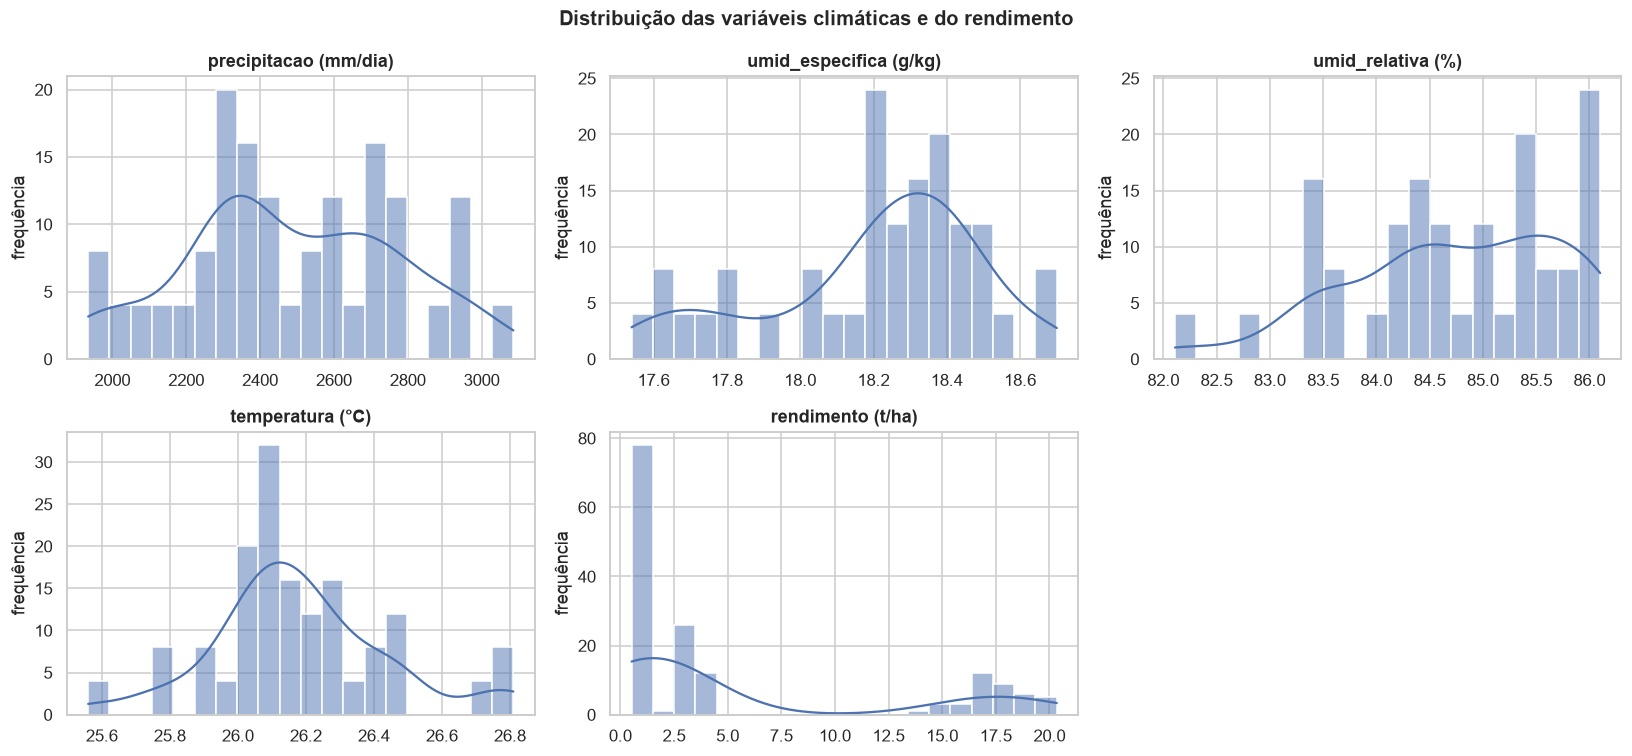

In [10]:
# Histograma com curva de densidade para cada variavel climatica e para o alvo
colunas_plot = VARIAVEIS_CLIMA + [ALVO]
fig, eixos = plt.subplots(2, 3, figsize=(15, 7))

for ax, coluna in zip(eixos.ravel(), colunas_plot):
    sns.histplot(data=df, x=coluna, kde=True, ax=ax, bins=20, edgecolor="white")
    unidade = UNIDADES.get(coluna, "t/ha")
    ax.set_title(f"{coluna} ({unidade})")
    ax.set_xlabel("")
    ax.set_ylabel("frequência")

# Remove o sexto subplot, que fica sem uso (5 variaveis em grade 2x3)
eixos.ravel()[-1].axis("off")
fig.suptitle("Distribuição das variáveis climáticas e do rendimento",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Achado.** O rendimento é a única variável com distribuição **fortemente
multimodal** — há picos separados por vazios, e não uma curva contínua. As
variáveis climáticas, por outro lado, são razoavelmente unimodais.

Essa multimodalidade não é ruído: é a assinatura das quatro culturas convivendo
na mesma coluna, cada uma com sua faixa própria de produtividade. A célula
seguinte torna isso explícito.

### 1.6 Rendimento por cultura — a escala que domina a base


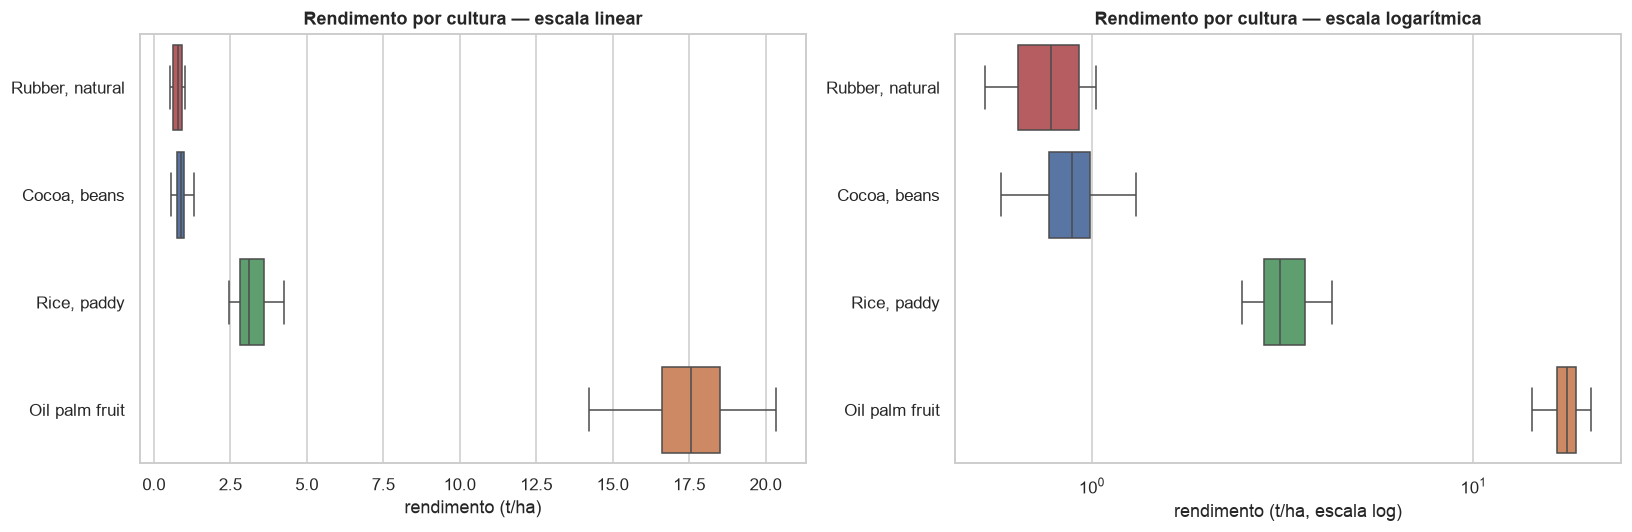

Cultura menos produtiva: Rubber, natural (0.78 t/ha)
Cultura mais produtiva:  Oil palm fruit (17.56 t/ha)
Razao entre elas: 22.5x


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Escala linear: revela a disparidade entre as culturas
ordem = df.groupby("cultura")[ALVO].median().sort_values().index
sns.boxplot(data=df, x=ALVO, y="cultura", order=ordem, ax=ax1, hue="cultura",
            legend=False)
ax1.set_title("Rendimento por cultura — escala linear")
ax1.set_xlabel("rendimento (t/ha)")
ax1.set_ylabel("")

# Escala logaritmica: permite comparar a dispersao interna de cada cultura
sns.boxplot(data=df, x=ALVO, y="cultura", order=ordem, ax=ax2, hue="cultura",
            legend=False)
ax2.set_xscale("log")
ax2.set_title("Rendimento por cultura — escala logarítmica")
ax2.set_xlabel("rendimento (t/ha, escala log)")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

# Quantifica a disparidade entre a cultura mais e a menos produtiva
medianas = df.groupby("cultura")[ALVO].median().sort_values()
razao = medianas.iloc[-1] / medianas.iloc[0]
print(f"Cultura menos produtiva: {medianas.index[0]} ({medianas.iloc[0]:.2f} t/ha)")
print(f"Cultura mais produtiva:  {medianas.index[-1]} ({medianas.iloc[-1]:.2f} t/ha)")
print(f"Razao entre elas: {razao:.1f}x")

**Achado central da exploração.** O dendê produz, na mediana, **22,5 vezes** mais
toneladas por hectare que a borracha natural. As faixas de rendimento das quatro
culturas são praticamente **disjuntas** — o gráfico da esquerda mostra os boxes
sem sobreposição.

Isso tem duas consequências diretas, que orientam todo o restante do notebook:

1. **Para a clusterização (seção 2):** qualquer algoritmo baseado em distância
   aplicado ao rendimento sem padronização vai separar as culturas, não os
   comportamentos produtivos. A padronização deixa de ser boa prática e passa a
   ser requisito.
2. **Para a correlação (seção 1.7):** uma correlação calculada sobre a base
   inteira vai medir a diferença **entre culturas**, e não o efeito do clima
   sobre a produtividade. É exatamente o que a próxima seção investiga.

### 1.7 Correlação: o que a análise global esconde


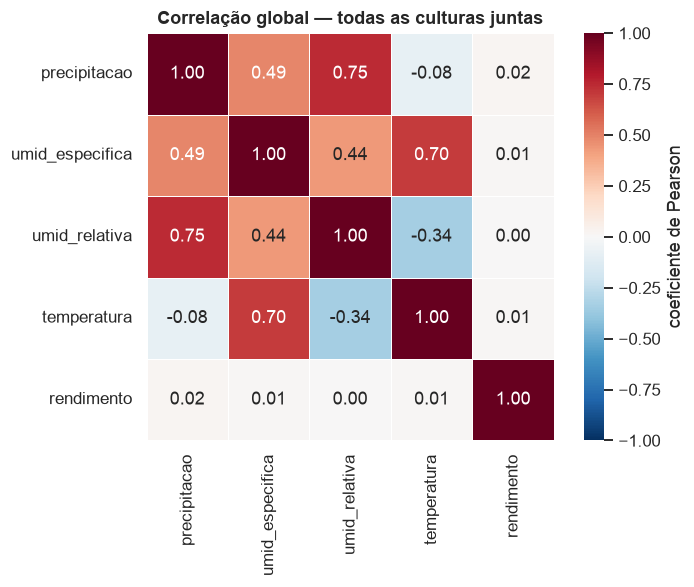

In [12]:
# Matriz de correlacao sobre a base inteira, ignorando a cultura
matriz_global = df[VARIAVEIS_CLIMA + [ALVO]].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(matriz_global, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "coeficiente de Pearson"})
plt.title("Correlação global — todas as culturas juntas")
plt.tight_layout()
plt.show()

In [13]:
# Correlacao de cada variavel climatica com o rendimento, calculada
# DENTRO de cada cultura - isola o efeito do clima do efeito da especie
correlacoes = {"GLOBAL (todas juntas)": matriz_global.loc[VARIAVEIS_CLIMA, ALVO]}

for cultura, grupo in df.groupby("cultura"):
    correlacoes[cultura] = grupo[VARIAVEIS_CLIMA + [ALVO]].corr().loc[VARIAVEIS_CLIMA, ALVO]

comparativo = pd.DataFrame(correlacoes).round(3)
comparativo.index.name = "variavel climatica"
comparativo

,GLOBAL (todas juntas),"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
variavel climatica,,,,,
precipitacao,0.02,0.17,0.22,0.33,0.10
umid_especifica,0.01,-0.06,0.07,0.70,-0.43
umid_relativa,0.00,-0.06,-0.04,0.15,-0.05
temperatura,0.01,-0.01,0.10,0.61,-0.41


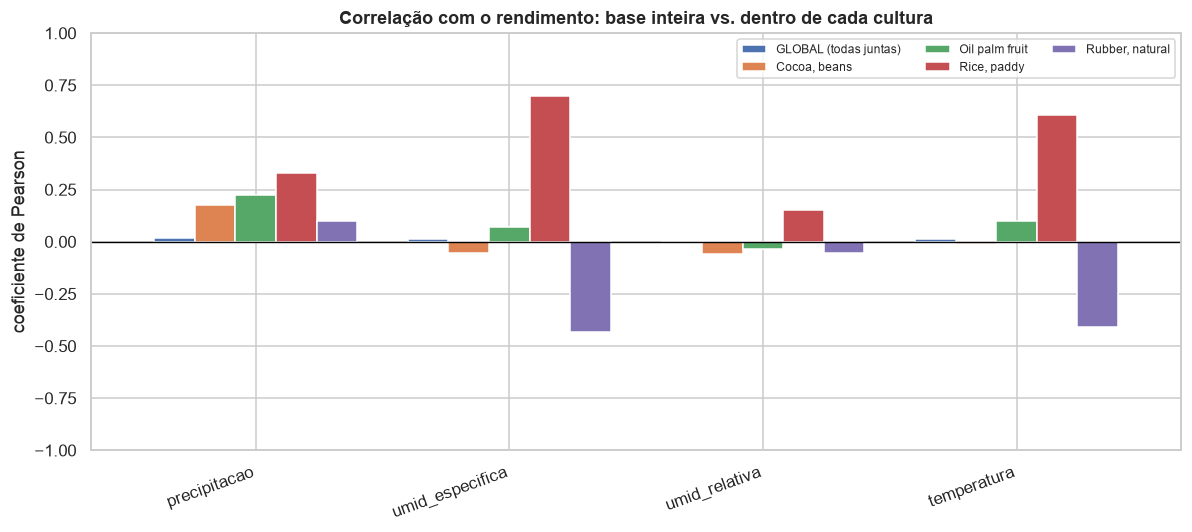

In [14]:
# Visualiza o contraste entre a leitura global e a leitura por cultura
plt.figure(figsize=(11, 5))
comparativo.plot(kind="bar", ax=plt.gca(), width=0.8, edgecolor="white")
plt.axhline(0, color="black", linewidth=0.9)
plt.title("Correlação com o rendimento: base inteira vs. dentro de cada cultura")
plt.ylabel("coeficiente de Pearson")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.legend(title="", fontsize=8, ncol=3)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

**Achado — a correlação global não é apenas fraca: ela cancela efeitos reais.**

Na base inteira, as quatro variáveis climáticas têm correlação praticamente nula
com o rendimento — entre **0,00 e 0,02**. Lida isoladamente, essa matriz levaria
à conclusão de que o clima não tem relação alguma com a produtividade, o que
inviabilizaria o próprio projeto.

Ao recalcular dentro de cada cultura, o quadro se inverte:

| Variável | Global | Arroz | Borracha |
|---|---|---|---|
| umidade específica | 0,01 | **+0,70** | **−0,43** |
| temperatura | 0,01 | **+0,61** | **−0,41** |

Os efeitos existem e são fortes — mas têm **sinais opostos entre culturas**. Mais
umidade específica e mais calor beneficiam o arroz e prejudicam a borracha. Ao
agregar as quatro culturas numa única correlação, esses efeitos contrários se
cancelam e o resultado converge para zero.

Este é um caso de **paradoxo de Simpson**: a associação observada no agregado
desaparece — ou se inverte — quando os dados são estratificados pelo grupo
correto. A `cultura` é a variável de confusão que dirige simultaneamente o clima
observado e o patamar de rendimento.

**Duas consequências diretas para a seção 3:**

1. `cultura` precisa entrar como preditor. Sem ela, o modelo enxergaria
   correlação zero e não teria o que aprender.
2. Não basta incluí-la como deslocamento de nível (*intercepto*). Como a
   **inclinação** da relação clima→rendimento muda de sinal entre culturas, é
   preciso capturar a **interação** entre cultura e clima. Modelos lineares só
   fazem isso com termos de interação explícitos; modelos baseados em árvore
   capturam interações por construção. **Hipótese a testar na seção 3: os modelos
   de árvore devem superar os lineares nesta base.**

### 1.8 Relação entre clima e rendimento, cultura a cultura


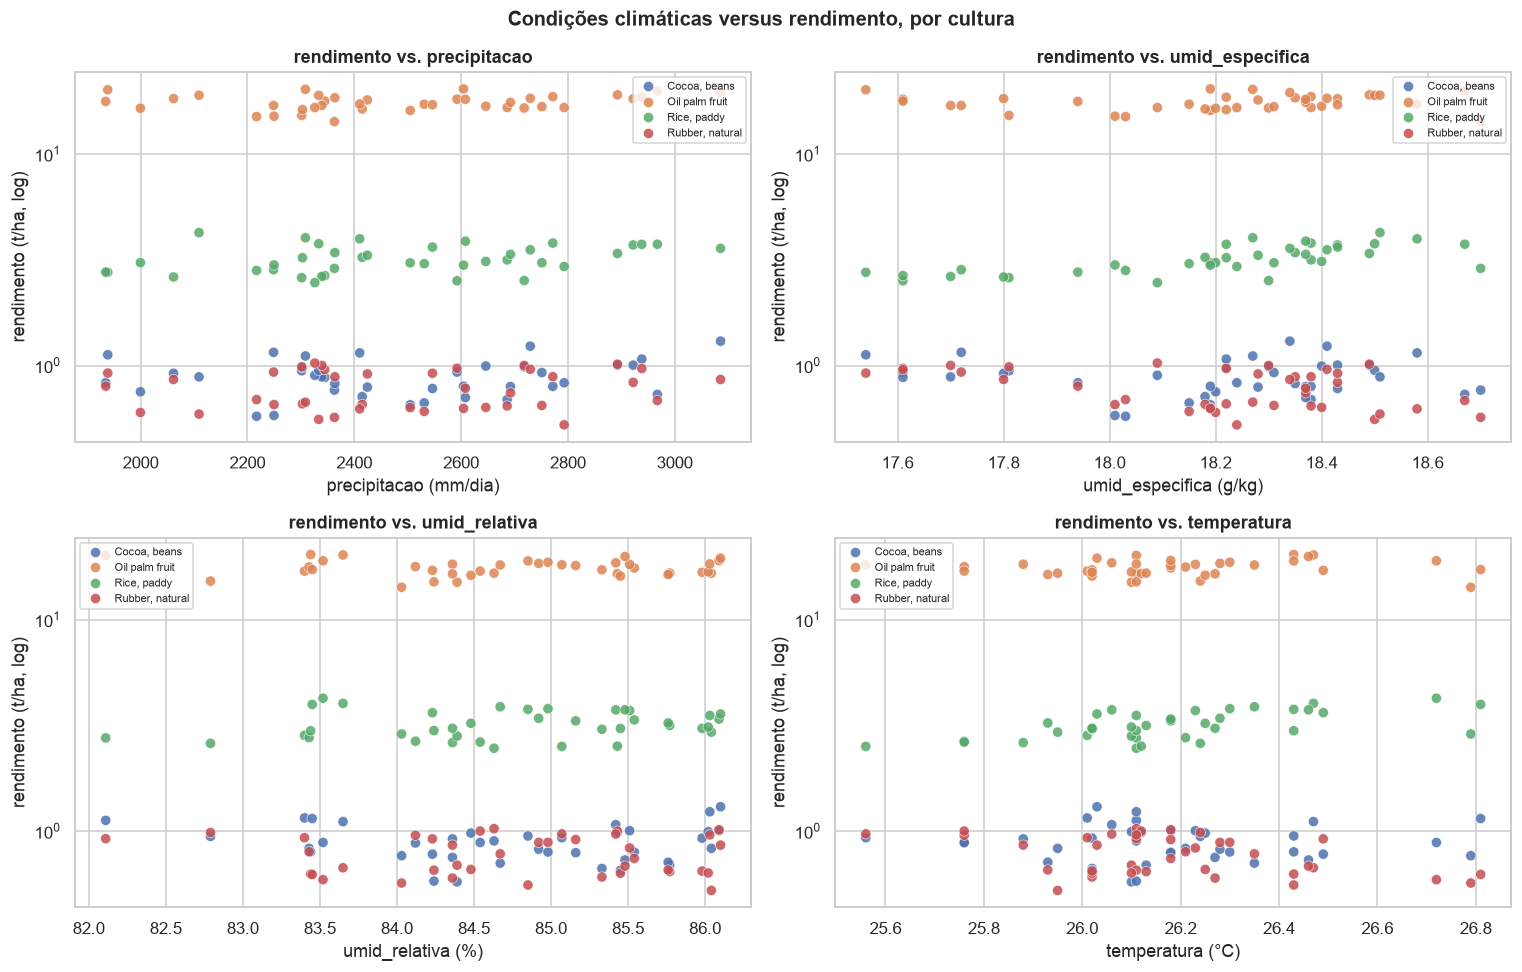

In [15]:
# Dispersao de cada variavel climatica contra o rendimento, colorida por cultura.
# A separacao visual por cor evidencia que cada cultura ocupa uma regiao propria.
fig, eixos = plt.subplots(2, 2, figsize=(14, 9))

for ax, variavel in zip(eixos.ravel(), VARIAVEIS_CLIMA):
    sns.scatterplot(data=df, x=variavel, y=ALVO, hue="cultura", ax=ax,
                    s=45, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_yscale("log")  # escala log: sem ela, dende achata as demais culturas
    ax.set_title(f"rendimento vs. {variavel}")
    ax.set_xlabel(f"{variavel} ({UNIDADES[variavel]})")
    ax.set_ylabel("rendimento (t/ha, log)")
    ax.legend(fontsize=7, title="")

fig.suptitle("Condições climáticas versus rendimento, por cultura",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Achado.** Cada cultura forma uma **nuvem horizontal própria e bem delimitada**.
Dentro de cada nuvem, a dispersão ao longo do eixo climático é ampla, mas a
variação vertical (de rendimento) é comparativamente estreita.

Em outras palavras: **saber qual é a cultura já determina a maior parte do
rendimento esperado**; o clima explica a variação restante, dentro daquela faixa.
Essa é a estrutura que os modelos da seção 3 precisarão capturar — e é também o
motivo pelo qual esperamos que a clusterização da seção 2 reencontre as culturas.

---

### Síntese da análise exploratória

| # | Achado | Impacto no trabalho |
|---|---|---|
| 1 | 156 observações, zero nulos, zero duplicatas | Nenhum tratamento de qualidade necessário |
| 2 | 4 culturas com exatamente 39 observações cada | Base balanceada; série provavelmente anual, mas **sem a coluna de ano** |
| 3 | `Yield` está em hg/ha, não em t/ha | Conversão aplicada (÷ 10.000) e validada contra referências da FAO |
| 4 | Rendimento varia 22,5× entre culturas (mediana), com faixas disjuntas | Padronização obrigatória antes de clusterizar |
| 5 | Correlação global ≈ 0, mas intra-cultura chega a +0,70 e −0,43 (paradoxo de Simpson) | `cultura` é confundidora; os modelos precisam capturar a interação cultura×clima |
| 6 | Cada cultura ocupa uma nuvem própria no espaço climático | A cultura determina o patamar; o clima explica a variação interna |
